# Synthetic data design — GT images & how the ground truth is built

This notebook visualises the **synthetic generator** (`scripts/make_realistic_cases.py` +
`docvlm_eval.synth`). For each case it shows the **GT image** and **how its ground truth is
designed** — with emphasis on the part that matters most: the **non-OCR understanding GT**.

The OCR GT (what string is where) falls out of the render for free. The valuable, harder GT —
*where is this word / table?*, *how many times does it appear?*, *what is the total?* and the
**reasoning** behind each — is derived **with no external model** (`docvlm_eval.synth.derive`),
purely from the rendered PDF's exact text positions + the values the generator already knows.
Every answer is therefore gold by construction.

Run order: Runtime → Run all. (Needs the `[synth]` extra: weasyprint + pymupdf + faker.)

In [28]:
# --- install docvlm_eval (fresh env e.g. Colab: clone+checkout; then editable install) ---
import os, sys, subprocess, importlib
from pathlib import Path

def _repo_root():
    for c in (Path.cwd(), Path.cwd().parent):
        if (c / "pyproject.toml").exists():
            return c
    return None

root = _repo_root()
if root is None:                       # fresh environment (Colab/Kaggle): clone the repo
    subprocess.run(["git", "clone", "https://github.com/SangbumChoi/OCR.git"], check=False)
    root = Path("OCR")
    subprocess.run(["git", "-C", str(root), "checkout", "claude/new-session-w79q0i"], check=False)
    subprocess.run(["git", "-C", str(root), "pull", "--ff-only"], check=False)
os.chdir(root)                         # cwd is now the repo root
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".[synth]"], check=True)

# The editable-install .pth is only read at interpreter startup, so a running kernel can't import
# the package until we add src/ to sys.path ourselves (avoids "No module named docvlm_eval").
src = str(Path.cwd() / "src")
if src not in sys.path:
    sys.path.insert(0, src)
importlib.invalidate_caches()
import docvlm_eval
print("docvlm_eval ready from", docvlm_eval.__file__)


docvlm_eval ready from /content/OCR/src/docvlm_eval/__init__.py


## 0. Setup + (re)generate the cases with the generator

In [29]:
import sys, json, subprocess
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

ROOT = Path.cwd()
if (ROOT / "scripts").exists() is False and (ROOT.parent / "scripts").exists():
    ROOT = ROOT.parent            # tolerate being launched from notebooks/
sys.path.insert(0, str(ROOT / "src"))
CASES_DIR = ROOT / "data" / "probes" / "realistic_cases"

# Fonts the cases need (CJK, Arabic, handwriting, serif) — without them WeasyPrint renders empty
# "tofu" boxes for ancient / RTL-Arabic / prescription. Install once (no-op if already present).
subprocess.run("apt-get -qq update && apt-get -qq install -y fonts-noto-cjk fonts-noto-core "
               "fonts-hosny-amiri fonts-tlwg-purisa fonts-ebgaramond fonts-liberation >/dev/null 2>&1; "
               "fc-cache -f >/dev/null 2>&1", shell=True)

# generate fresh (clean only = fast); each gt.json is the structured DocSample DTO
subprocess.run([sys.executable, "scripts/make_realistic_cases.py", "--no-degrade"], cwd=ROOT, check=True)
print("cases:", sorted(p.name for p in CASES_DIR.iterdir() if p.is_dir()))

# rendering sanity: flag any case whose page is almost blank (a hint of missing-font tofu)
import numpy as np
for k in sorted(p.name for p in CASES_DIR.iterdir() if p.is_dir()):
    a = np.asarray(Image.open(CASES_DIR/k/"clean.png").convert("L"))
    ink = float((a < 128).mean())
    if ink < 0.002:
        print(f"  [check] {k}: very little ink ({ink:.4f}) — verify fonts rendered (not tofu)")

cases: ['ancient', 'bank_statement', 'checkbox_form', 'cheque', 'id_card', 'invoice', 'lcd_7seg', 'mobile_app', 'pdf_paper', 'prescription', 'redacted', 'rtl_arabic', 'website', 'webtoon']


## 1. Helper — overlay GT boxes and list the *designed* GT

`fields_detailed[].bbox` = OCR/KIE spotting boxes (green). The **understanding** layer adds, in
distinct colours: **locate** (a word's box, red), **region** (a table/region box, blue). Below each
image we print the derived understanding QAs — *question → answer → reasoning* — so you can see
exactly how the GT was designed.

In [30]:
UNDERSTANDING = {"L1-locate", "L1-region", "H-count", "H1-aggregate"}
COLOR = {"field": "#1a9641", "L1-locate": "#d7191c", "L1-region": "#2c7bb6"}

def load_case(key):
    d = json.loads((CASES_DIR / key / "gt.json").read_text())
    img = Image.open(CASES_DIR / key / "clean.png").convert("RGB")
    return d, img

def show_case(key):
    """One full card per case: the GT image with overlays, the document text it contains, and EVERY
    task it defines (question -> answer -> reasoning), so it's clear what can be learned/evaluated."""
    gt, img = load_case(key)
    fig, ax = plt.subplots(figsize=(7, 7 * img.height / img.width))
    ax.imshow(img); ax.set_axis_off()
    ax.set_title(f"{key}  ·  {gt.get('type','')}", fontsize=11)

    def rect(b, color, label):
        ax.add_patch(mpatches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                     fill=False, edgecolor=color, linewidth=1.8))
        ax.text(b[0], max(0, b[1]-4), label, color=color, fontsize=7,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.6, pad=0.5))
    for f in gt.get("fields_detailed", []):
        if f.get("bbox"):
            rect(f["bbox"], COLOR["field"], f["key"])                 # field / KIE spot (green)
    for q in gt.get("qa_detailed", []):
        if q.get("answer_bbox") and q["answer_type"] in ("L1-locate", "L1-region"):
            rect(q["answer_bbox"], COLOR[q["answer_type"]],
                 "locate" if q["answer_type"] == "L1-locate" else "region")  # red / blue
    plt.tight_layout(); plt.show()

    print(f"TYPE      : {gt.get('type','')}   domain={gt.get('domain')}  "
          f"acquisition={gt.get('acquisition')}  langs={gt.get('languages')}")
    # what document TEXT/INFO is on the page (the OCR-side GT)
    flds = [f for f in gt.get("fields_detailed", []) if f.get("value")]
    if flds:
        print("DOCUMENT TEXT (fields):")
        for f in flds:
            v = f["value"] if len(f["value"]) <= 48 else f["value"][:48] + "…"
            tags = []
            if f.get("language", "en") != "en": tags.append(f"{f['language']}/{f.get('script')}")
            if f.get("is_small"): tags.append("small-text")
            if f.get("bbox"): tags.append("box")
            print(f"   - {f['key']:18}: {v!r}  {('· ' + ' '.join(tags)) if tags else ''}")
    # what TASKS the case defines (every QA + control probe), with answer + reasoning
    print("TASKS (what a model is asked to do):")
    for q in gt.get("qa_detailed", []):
        mark = "★" if q["answer_type"] in UNDERSTANDING else " "
        print(f"  {mark}[{q['answer_type']:12}] {q['question']}")
        print(f"        → answer: {q['answers'][0]}   (metric={q['metric']})")
        if q.get("rationale"):
            print(f"        → reasoning: {q['rationale']}")
    for pr in gt.get("probes", []):
        print(f"   [probe:{pr['kind']:9}] {pr['question']}   → expect: {pr['expected']}")
    if gt.get("table_html"):
        print(f"   [table       ] convert the table to HTML (TEDS gold, {gt['table_html'][:30]}…)")
    sup = gt.get("ablation_support", {})
    print("SUPPORTS  :", {k: v for k, v in sup.items() if v}, "   (★ = model-free understanding GT)")
    print("=" * 100)

## 2. Gallery — every case drawn like the invoice example

For each generated document: the **GT image with overlays** (green=field/KIE box, red=locate, blue=region), the **document text** it contains, and **every task** it defines — question → answer → *reasoning* (★ marks the model-free understanding GT: locate / region / count / sum).

14 synthetic cases: ['ancient', 'bank_statement', 'checkbox_form', 'cheque', 'id_card', 'invoice', 'lcd_7seg', 'mobile_app', 'pdf_paper', 'prescription', 'redacted', 'rtl_arabic', 'website', 'webtoon'] 



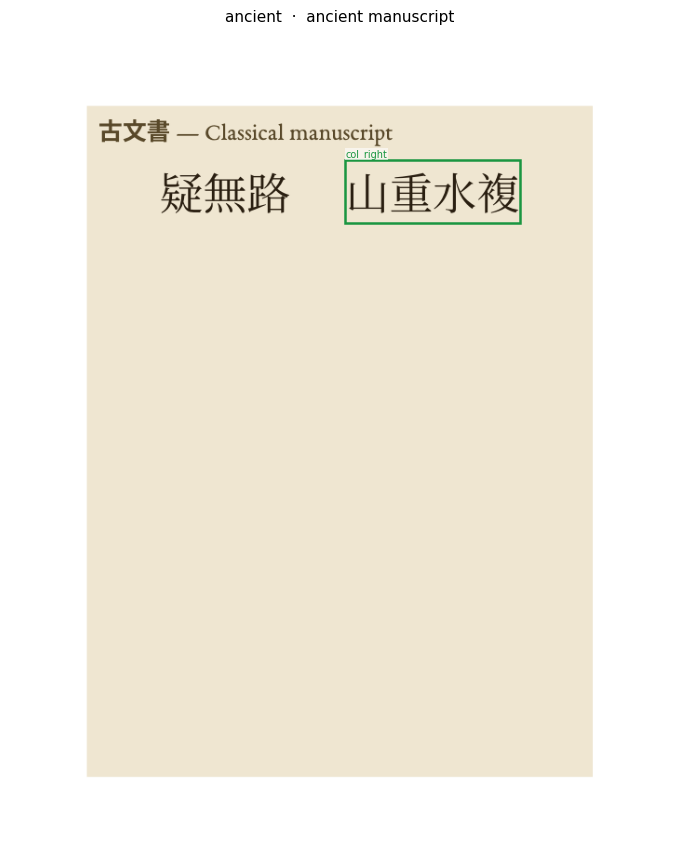

TYPE      : ancient manuscript   domain=None  acquisition=None  langs=['en']
DOCUMENT TEXT (fields):
   - transcript        : '山重水複疑無路'  
   - reading_direction : 'vertical-rtl'  
TASKS (what a model is asked to do):
   [multilingual] Transcribe the characters (top→bottom, right→left). Answer concisely, no explanation.
        → answer: 山重水複疑無路   (metric=ned)
SUPPORTS  : {'spotting': True}    (★ = model-free understanding GT)


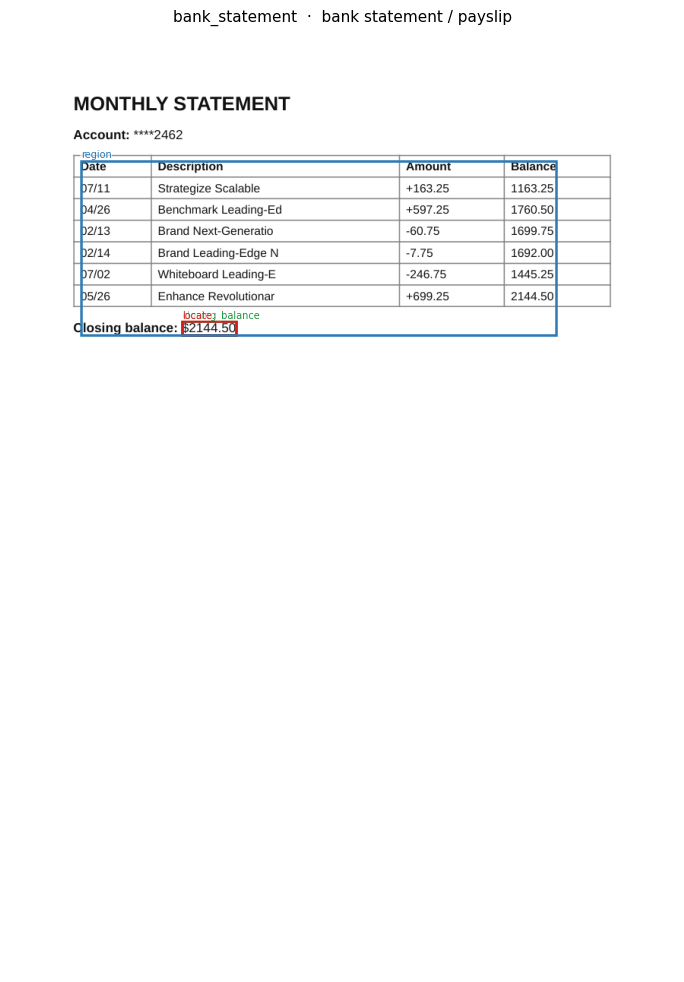

TYPE      : bank statement / payslip   domain=finance  acquisition=scan  langs=['en']
DOCUMENT TEXT (fields):
   - account           : '****2462'  
   - txns_rows         : '6'  
   - closing_balance   : '$2144.50'  · box
TASKS (what a model is asked to do):
   [kie         ] What is the closing balance? Answer concisely, no explanation.
        → answer: $2144.50   (metric=anls)
  ★[L1-locate   ] Where is the closing balance located? Return its bounding box as [x1, y1, x2, y2] in pixel coordinates. The image is 875x1241 pixels.
        → answer: 226,383,297,402;875,1241   (metric=grounding)
        → reasoning: the closing balance is rendered at [226, 383, 297, 402] on the 875x1241px page.
  ★[L1-region   ] Where is the transaction table located? Return its bounding box as [x1, y1, x2, y2] in pixel coordinates. The image is 875x1241 pixels.
        → answer: 93,172,719,402;875,1241   (metric=grounding)
        → reasoning: the transaction table is rendered at [93, 172, 719, 402] on th

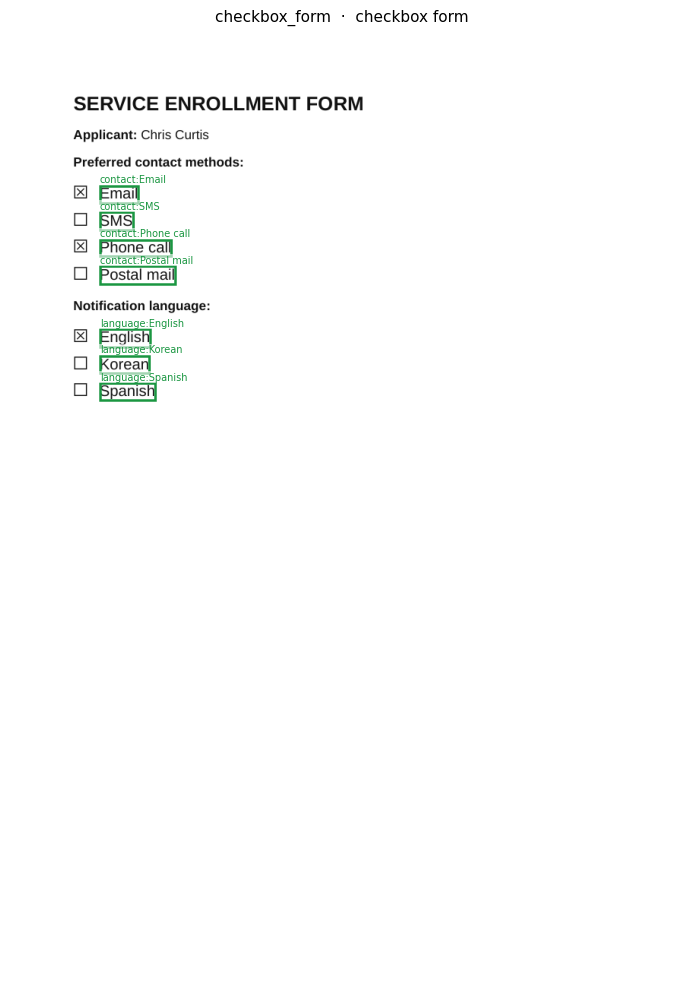

TYPE      : checkbox form   domain=None  acquisition=None  langs=['en']
DOCUMENT TEXT (fields):
   - applicant         : 'Chris Curtis'  
TASKS (what a model is asked to do):
   [selection   ] Which contact methods are checked? Answer concisely, no explanation.
        → answer: Email, Phone call   (metric=anls)
   [selection   ] Which notification language is checked? Answer concisely, no explanation.
        → answer: English   (metric=anls)
   [probe:abstain  ] Is 'Fax' selected?   → expect: option not present
SUPPORTS  : {'spotting': True, 'abstain': True}    (★ = model-free understanding GT)


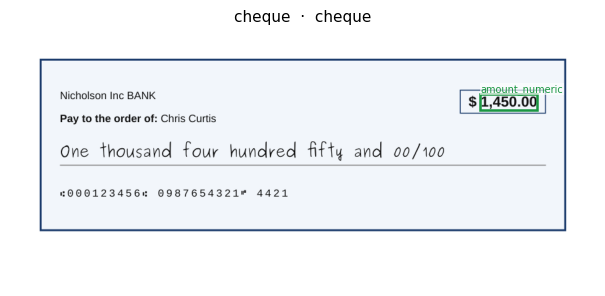

TYPE      : cheque   domain=finance  acquisition=scan  langs=['en']
DOCUMENT TEXT (fields):
   - amount_numeric    : '1,450.00'  · box
   - payee             : 'Chris Curtis'  
   - amount_words      : 'One thousand four hundred fifty and 00/100'  
TASKS (what a model is asked to do):
   [kie         ] What is the numeric (courtesy) amount on the cheque? Answer concisely, no explanation.
        → answer: 1,450.00   (metric=anls)
   [kie         ] Who is the payee? Answer concisely, no explanation.
        → answer: Chris Curtis   (metric=ned)
   [consistency ] Do the numeric and written amounts agree? Answer concisely, no explanation.
        → answer: yes   (metric=anls)
        → reasoning: Numeric '1,450.00' equals legal 'one thousand four hundred fifty' → they agree.
   [probe:consistency] Do the numeric and written amounts agree?   → expect: yes (1450.00 == one thousand four hundred fifty)
SUPPORTS  : {'spotting': True, 'rationale': True}    (★ = model-free understanding GT)


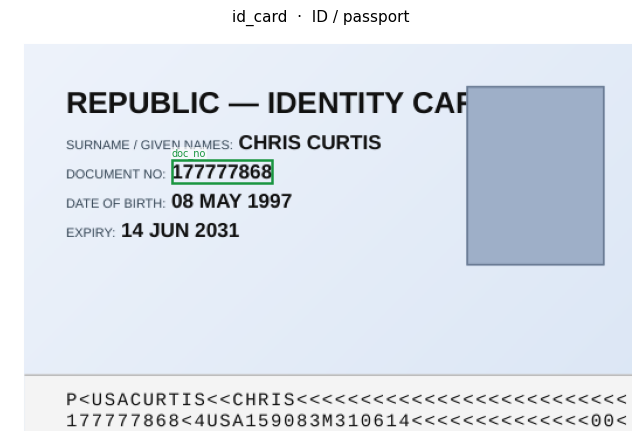

TYPE      : ID / passport   domain=None  acquisition=None  langs=['en']
DOCUMENT TEXT (fields):
   - name              : 'CHRIS CURTIS'  
   - doc_no            : '177777868'  · box
   - dob               : '08 MAY 1997'  
   - expiry            : '14 JUN 2031'  
   - mrz1              : 'P<USACURTIS<<CHRIS<<<<<<<<<<<<<<<<<<<<<<<<<<'  · small-text
   - mrz2              : '177777868<4USA159083M310614<<<<<<<<<<<<<<00<'  · small-text
TASKS (what a model is asked to do):
   [kie         ] What is the document number? Answer concisely, no explanation.
        → answer: 177777868   (metric=ned)
   [kie         ] What is the cardholder's full name? Answer concisely, no explanation.
        → answer: CHRIS CURTIS   (metric=ned)
   [probe:abstain  ] What is the cardholder's blood type?   → expect: not present — abstain
SUPPORTS  : {'spotting': True, 'small_text': True, 'abstain': True}    (★ = model-free understanding GT)


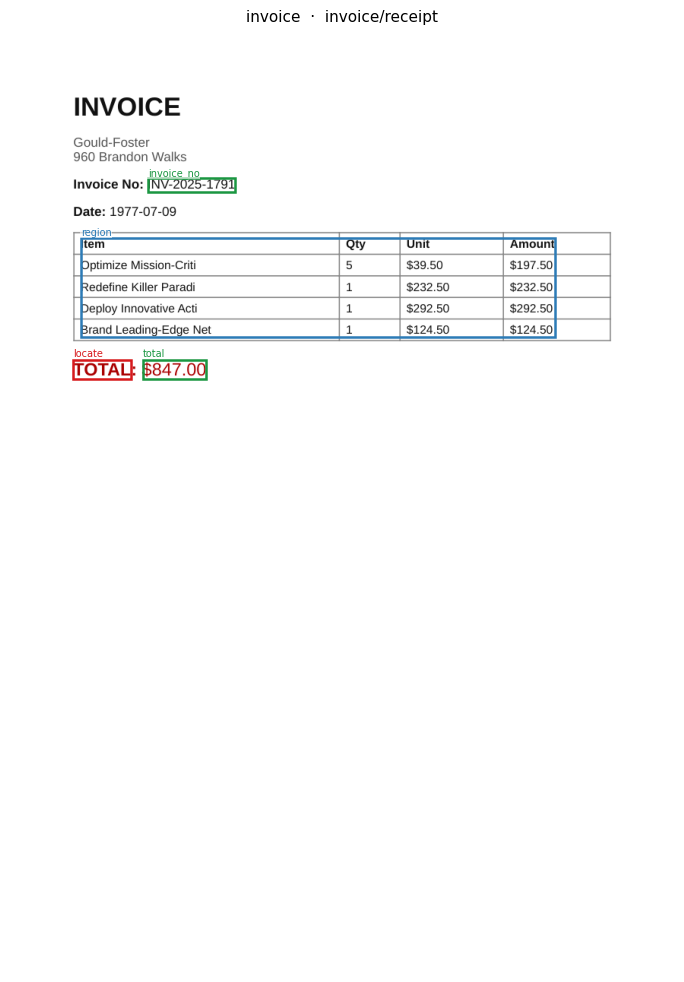

TYPE      : invoice/receipt   domain=finance  acquisition=scan  langs=['en']
DOCUMENT TEXT (fields):
   - invoice_no        : 'INV-2025-1791'  · box
   - date              : '1977-07-09'  
   - lines_rows        : '4'  
   - total             : '$847.00'  · box
TASKS (what a model is asked to do):
   [kie         ] What is the invoice number? Answer concisely, no explanation.
        → answer: INV-2025-1791   (metric=ned)
   [kie         ] What is the total amount? Answer concisely, no explanation.
        → answer: $847.00   (metric=anls)
        → reasoning: Sum the line amounts: 5×$39.50 + 1×$232.50 + 1×$292.50 + 1×$124.50 = $847.00.
  ★[L1-locate   ] Where is the TOTAL row located? Return its bounding box as [x1, y1, x2, y2] in pixel coordinates. The image is 875x1241 pixels.
        → answer: 83,434,159,460;875,1241   (metric=grounding)
        → reasoning: the TOTAL row is rendered at [83, 434, 159, 460] on the 875x1241px page.
  ★[L1-region   ] Where is the line-item table locat

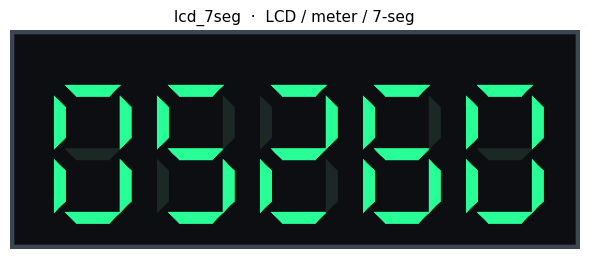

TYPE      : LCD / meter / 7-seg   domain=None  acquisition=None  langs=['en']
DOCUMENT TEXT (fields):
   - reading           : '05260'  
TASKS (what a model is asked to do):
   [special-glyph] What number is on the display?
        → answer: 05260   (metric=exact)
SUPPORTS  : {}    (★ = model-free understanding GT)


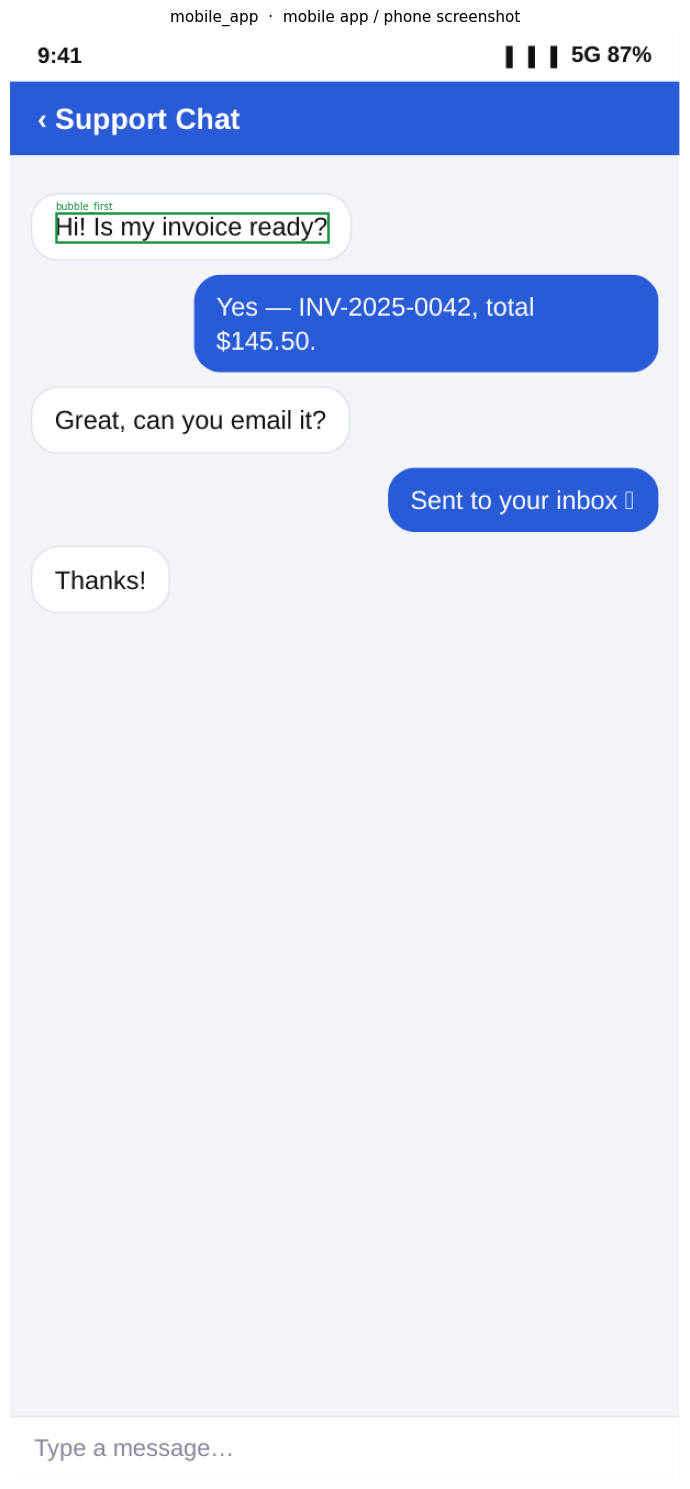

TYPE      : mobile app / phone screenshot   domain=None  acquisition=None  langs=['en']
DOCUMENT TEXT (fields):
   - messages          : "['Hi! Is my invoice ready?', 'Yes — INV-2025-004…"  
TASKS (what a model is asked to do):
   [reading-order] Transcribe the chat messages in order, one per line. Answer concisely, no explanation.
        → answer: Hi! Is my invoice ready?
Yes — INV-2025-0042, total $145.50.
Great, can you email it?
Sent to your inbox ✅
Thanks!   (metric=ned)
   [probe:direction] Which messages are the user's?   → expect: right/blue bubbles = user (outgoing)
SUPPORTS  : {'spotting': True, 'reading_order': True}    (★ = model-free understanding GT)


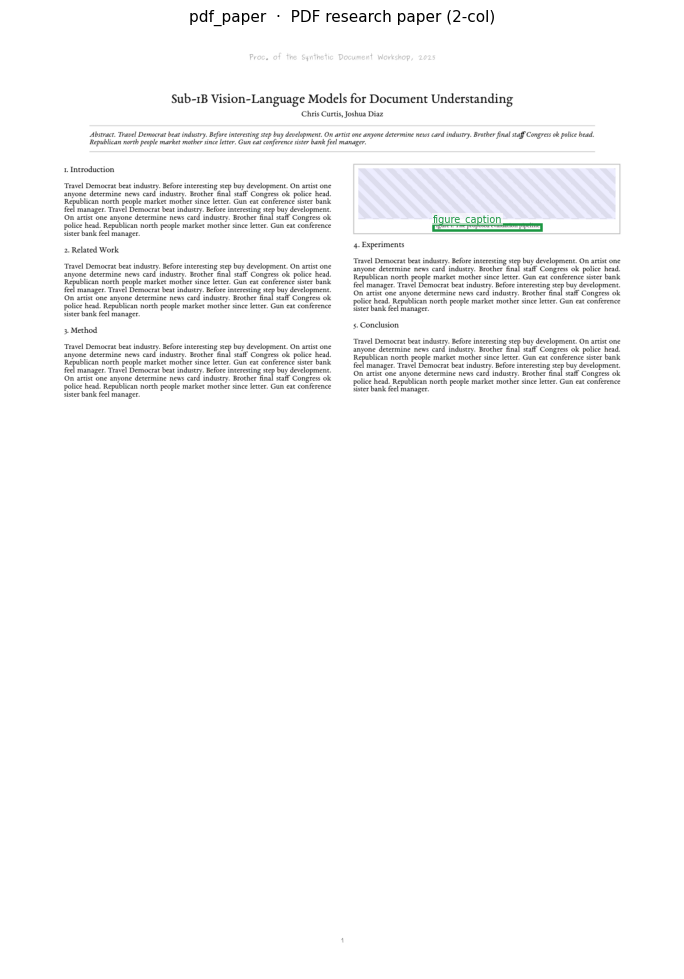

TYPE      : PDF research paper (2-col)   domain=None  acquisition=None  langs=['en']
DOCUMENT TEXT (fields):
   - title             : 'Sub-1B Vision-Language Models for Document Under…'  
   - authors           : 'Chris Curtis, Joshua Diaz'  
   - sections          : "['1. Introduction', '2. Related Work', '3. Metho…"  
TASKS (what a model is asked to do):
   [ui          ] What is the paper title? Answer concisely, no explanation.
        → answer: Sub-1B Vision-Language Models for Document Understanding   (metric=ned)
   [reading-order] List the section headings in order. Answer concisely, no explanation.
        → answer: 1. Introduction; 2. Related Work; 3. Method; 4. Experiments; 5. Conclusion   (metric=ned)
   [probe:order    ] Does text read across both columns row-by-row?   → expect: no — each column reads top-to-bottom independently
SUPPORTS  : {'spotting': True, 'reading_order': True}    (★ = model-free understanding GT)


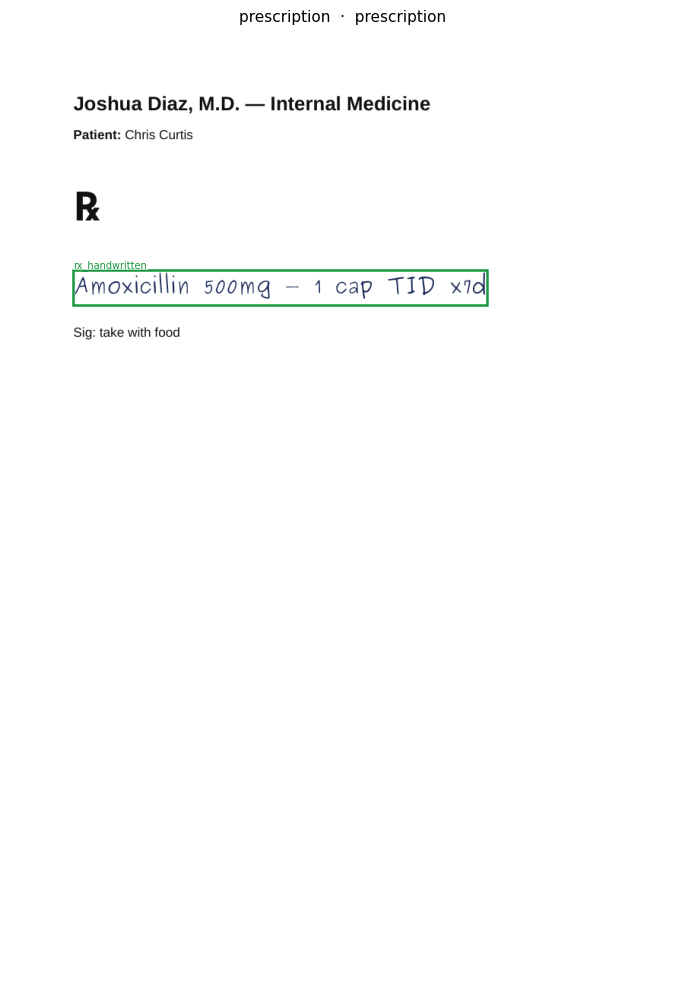

TYPE      : prescription   domain=None  acquisition=None  langs=['en']
DOCUMENT TEXT (fields):
   - patient           : 'Chris Curtis'  
   - rx_handwritten    : 'Amoxicillin 500mg — 1 cap TID x7d'  · box
TASKS (what a model is asked to do):
   [handwriting ] Transcribe the handwritten medication line. Answer concisely, no explanation.
        → answer: Amoxicillin 500mg — 1 cap TID x7d   (metric=ned)
   [probe:abstain  ] What is the refill count?   → expect: not legible / not present — abstain
SUPPORTS  : {'spotting': True, 'abstain': True}    (★ = model-free understanding GT)


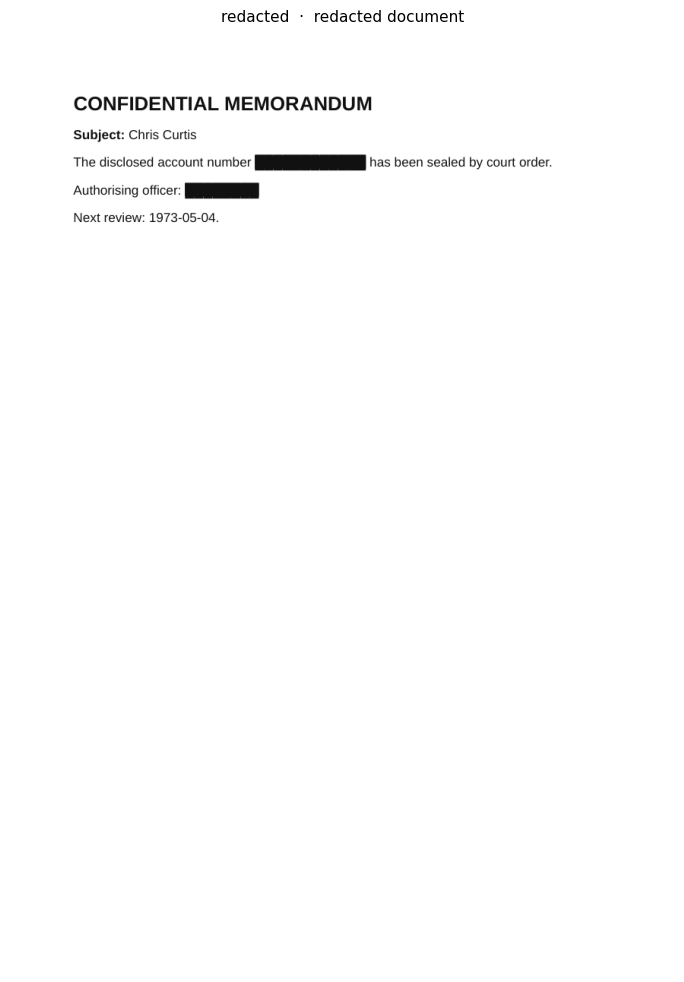

TYPE      : redacted document   domain=None  acquisition=None  langs=['en']
DOCUMENT TEXT (fields):
   - subject           : 'Chris Curtis'  
TASKS (what a model is asked to do):
   [kie         ] Who is the subject of the memo? Answer concisely, no explanation.
        → answer: Chris Curtis   (metric=ned)
   [probe:abstain  ] What is the account number?   → expect: [redacted] — blacked out; must NOT invent a value
   [probe:abstain  ] What is the authorising officer?   → expect: [redacted] — blacked out; must NOT invent a value
SUPPORTS  : {'abstain': True}    (★ = model-free understanding GT)


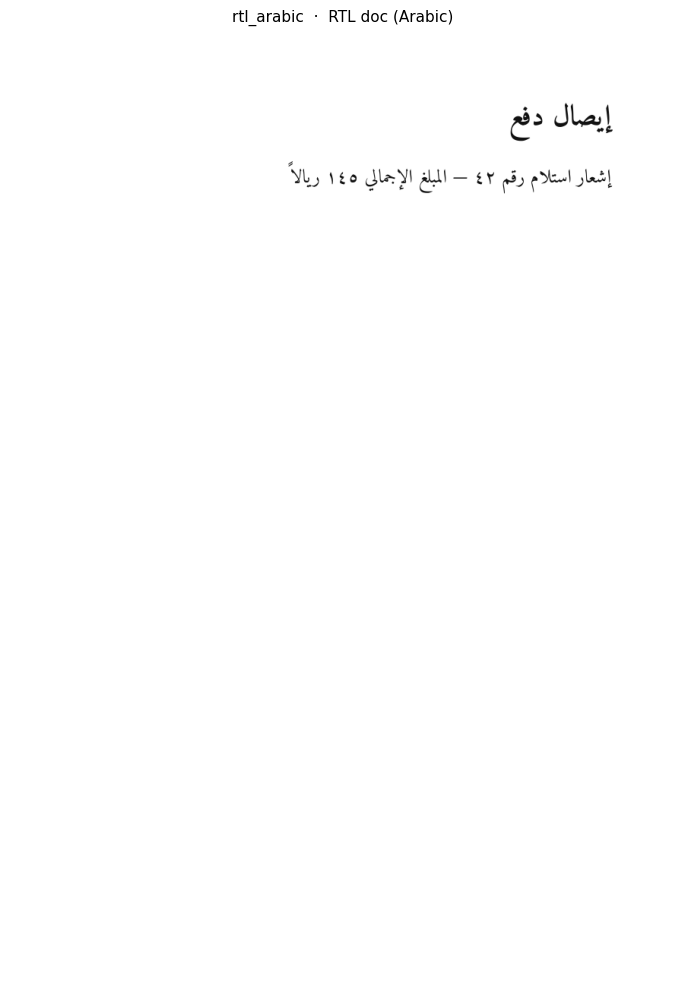

TYPE      : RTL doc (Arabic)   domain=None  acquisition=None  langs=['en']
DOCUMENT TEXT (fields):
   - transcript        : 'إشعار استلام رقم ٤٢ — المبلغ الإجمالي ١٤٥ ريالاً'  · ar/arabic
   - language          : 'ar'  
   - reading_direction : 'rtl'  
TASKS (what a model is asked to do):
   [multilingual] Transcribe the Arabic text in the image. Answer concisely, no explanation.
        → answer: إشعار استلام رقم ٤٢ — المبلغ الإجمالي ١٤٥ ريالاً   (metric=ned)
   [direction   ] Is the text right-to-left or left-to-right? Answer concisely, no explanation.
        → answer: right-to-left   (metric=exact)
   [probe:direction] Is this text right-to-left or left-to-right?   → expect: right-to-left
SUPPORTS  : {'multilingual': True}    (★ = model-free understanding GT)


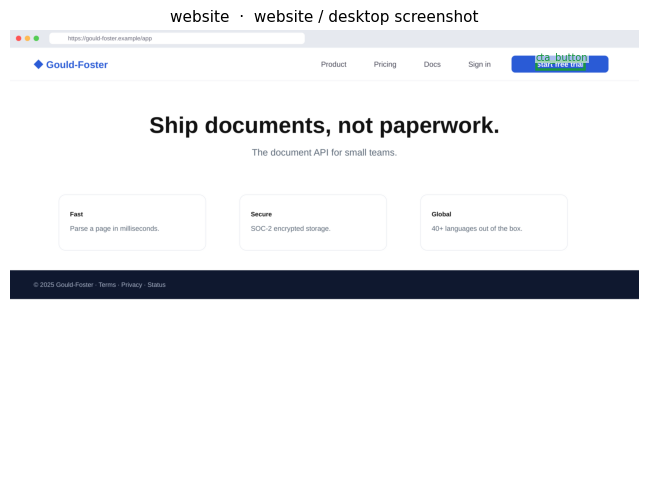

TYPE      : website / desktop screenshot   domain=None  acquisition=None  langs=['en']
DOCUMENT TEXT (fields):
   - brand             : 'Gould-Foster'  
   - nav_items         : "['Product', 'Pricing', 'Docs', 'Sign in']"  
   - headline          : 'Ship documents, not paperwork.'  
   - cta               : 'Start free trial'  
TASKS (what a model is asked to do):
   [ui          ] List the navigation menu items in order. Answer concisely, no explanation.
        → answer: Product, Pricing, Docs, Sign in   (metric=ned)
   [ui          ] What is the main headline? Answer concisely, no explanation.
        → answer: Ship documents, not paperwork.   (metric=ned)
   [probe:abstain  ] What is the user's logged-in email?   → expect: logged-out page — abstain
SUPPORTS  : {'spotting': True, 'abstain': True, 'reading_order': True}    (★ = model-free understanding GT)


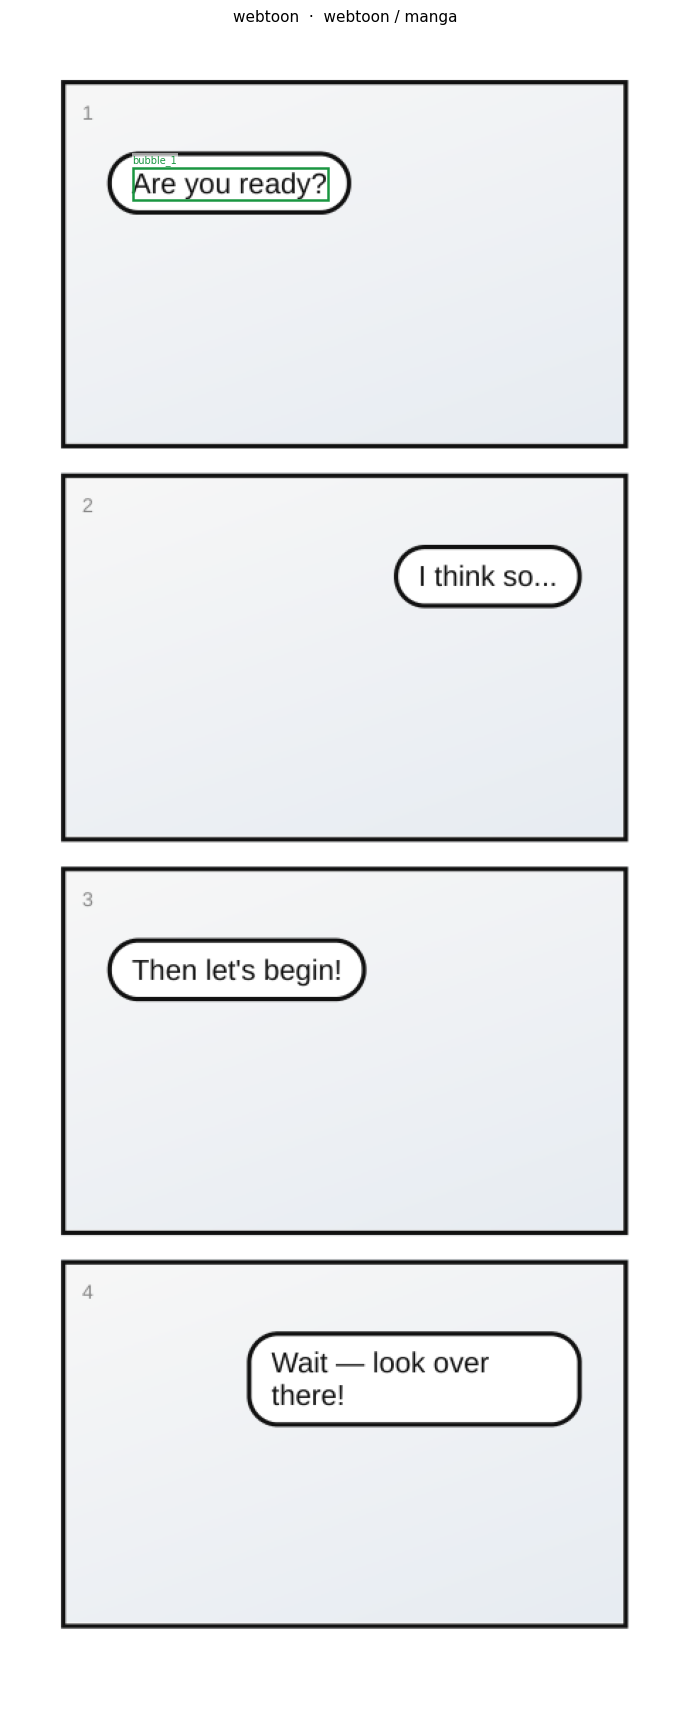

TYPE      : webtoon / manga   domain=None  acquisition=None  langs=['en']
DOCUMENT TEXT (fields):
   - n_panels          : '4'  
TASKS (what a model is asked to do):
   [reading-order] Transcribe the speech bubbles top to bottom, one per line. Answer concisely, no explanation.
        → answer: Are you ready?
I think so...
Then let's begin!
Wait — look over there!   (metric=ned)
SUPPORTS  : {'spotting': True, 'reading_order': True}    (★ = model-free understanding GT)


In [31]:
# Full gallery: draw every generated case like the invoice example — GT image + tasks + reasoning.
cases = sorted(p.name for p in CASES_DIR.iterdir() if p.is_dir())
print(f"{len(cases)} synthetic cases:", cases, "\n")
for key in cases:
    show_case(key)

## 3. How each GT type is designed (model-free)

| GT type | Question it answers | Derived from | Reasoning it emits |
| --- | --- | --- | --- |
| `L1-locate` | *Where is this word?* | exact text box from the rendered PDF | "'X' is at [x1,y1,x2,y2]" |
| `L1-region` | *Where is this table/region?* | union of the member strings' boxes | spans [..] enclosing the cells |
| `H-count` | *How many times does X appear?* | count of the word's hits on the page | the N hit positions |
| `H1-aggregate` | *What is the total?* | arithmetic over known values | the worked sum `a + b + c = T` |

No external model is used — only PyMuPDF text positions + arithmetic — so all answers are exact.
Each is one `DocBuilder.ask_*` call (`ask_where` / `ask_region` / `ask_count` / `ask_aggregate`).

## 4. Flexibility — toggle the understanding layer as one ablation switch

`emit_understanding` in `configs/synth_data.yaml` (or `--ablation U_understanding_off`) includes or
removes the whole understanding layer, so its contribution can be ablated in isolation.

In [32]:
for arm in ["U_understanding_on", "U_understanding_off"]:
    subprocess.run([sys.executable, "scripts/make_realistic_cases.py", "--only", "invoice",
                    "--no-degrade", "--ablation", arm], cwd=ROOT, check=True)
    gt = json.loads((CASES_DIR / "invoice" / "gt.json").read_text())
    n = sum(q["answer_type"] in UNDERSTANDING for q in gt.get("qa_detailed", []))
    print(f"{arm:22} -> {n} understanding QAs")
# restore the full baseline
subprocess.run([sys.executable, "scripts/make_realistic_cases.py", "--no-degrade"], cwd=ROOT, check=True)

U_understanding_on     -> 4 understanding QAs
U_understanding_off    -> 0 understanding QAs


CompletedProcess(args=['/usr/bin/python3', 'scripts/make_realistic_cases.py', '--no-degrade'], returncode=0)

## 5. At-a-glance index (thumbnails + support flags)

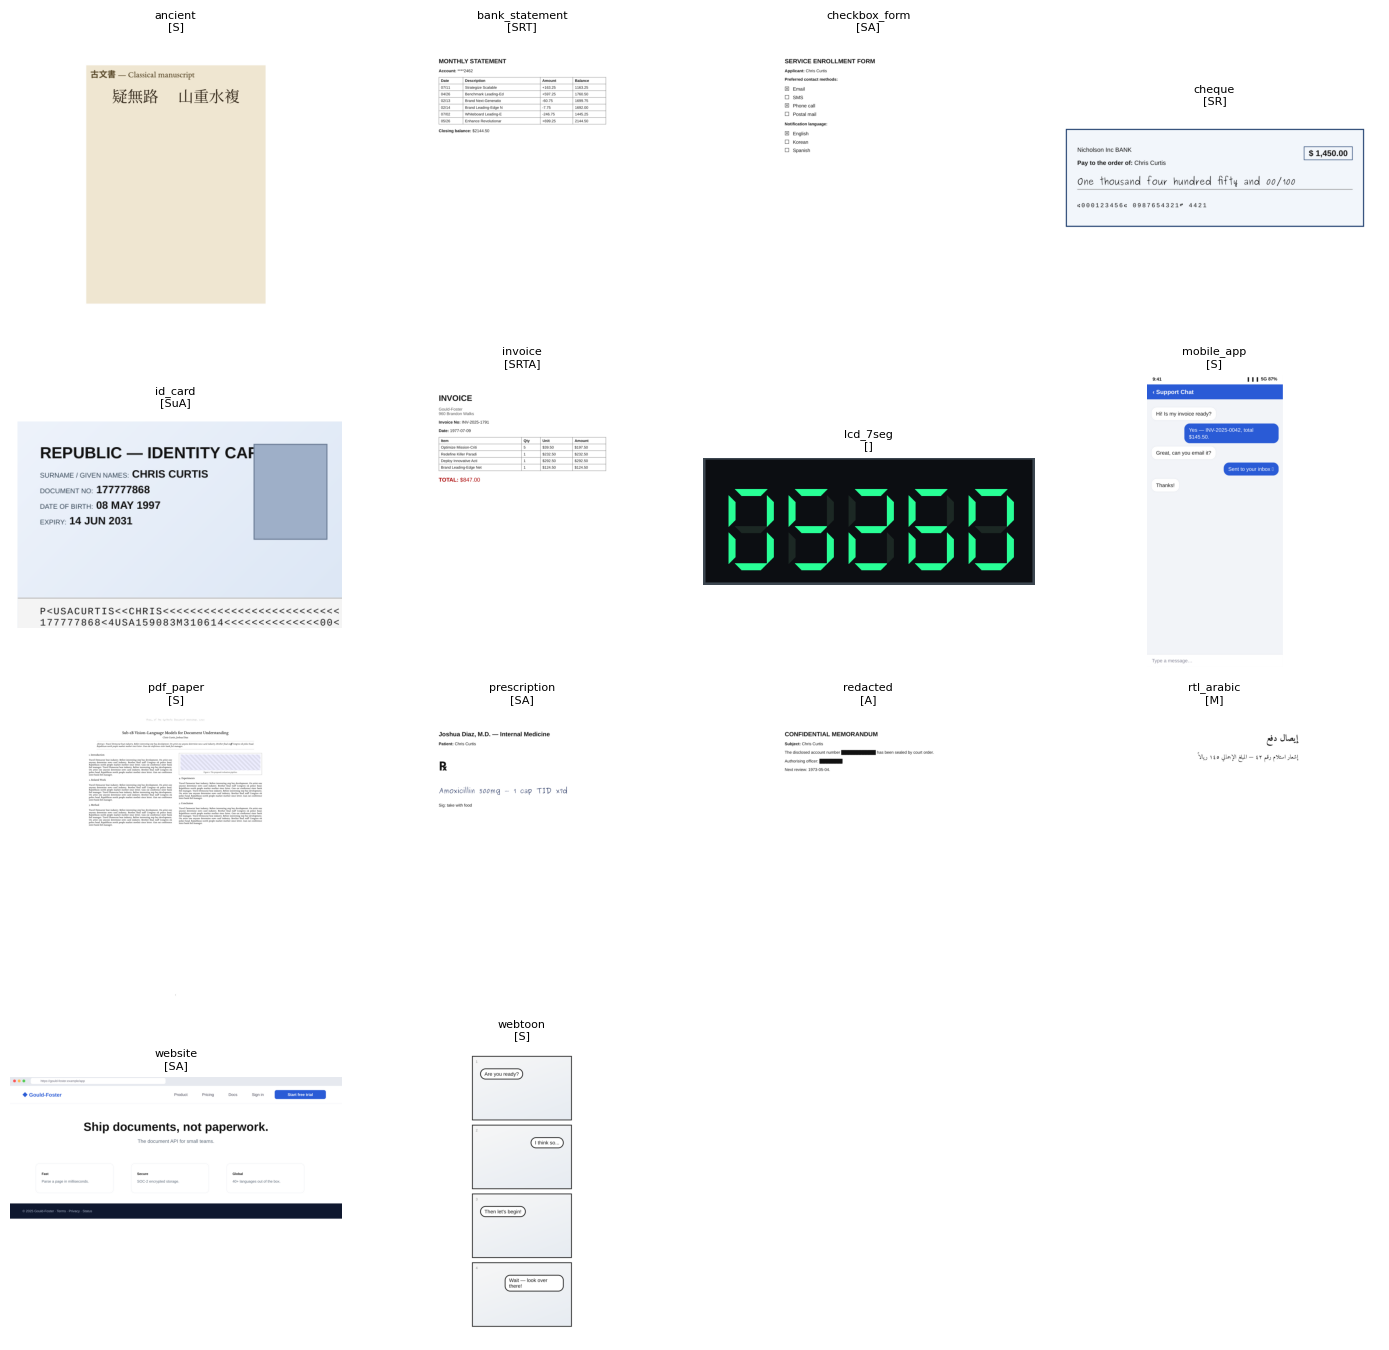

flags: S=spotting R=rationale M=multilingual u=small-text T=table A=abstain


In [33]:
# Compact at-a-glance index of all cases with their ablation-support flags.
keys = sorted(p.name for p in CASES_DIR.iterdir() if p.is_dir())
cols = 4; rows = (len(keys) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, 3.4 * rows))
for ax, key in zip(axes.ravel(), keys):
    gt, img = load_case(key)
    ax.imshow(img); ax.set_axis_off()
    flags = "".join(c for c, on in [("S","spotting"),("R","rationale"),("M","multilingual"),
            ("u","small_text"),("T","table"),("A","abstain")]
            if gt.get("ablation_support", {}).get(on))
    ax.set_title(f"{key}\n[{flags}]", fontsize=8)
for ax in axes.ravel()[len(keys):]:
    ax.set_axis_off()
plt.tight_layout(); plt.show()
print("flags: S=spotting R=rationale M=multilingual u=small-text T=table A=abstain")